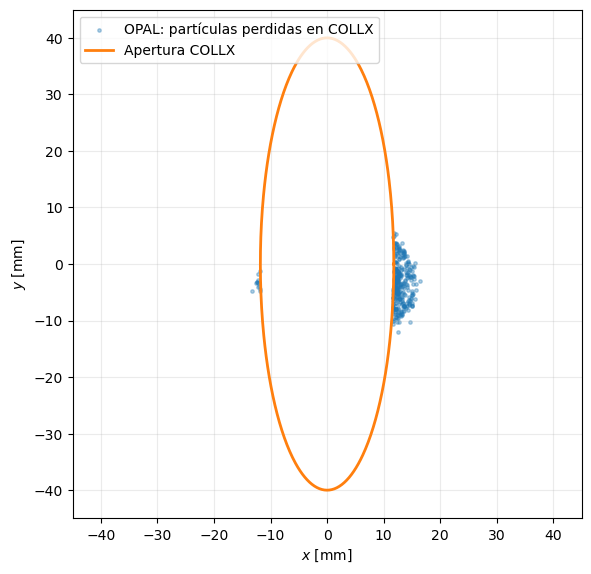

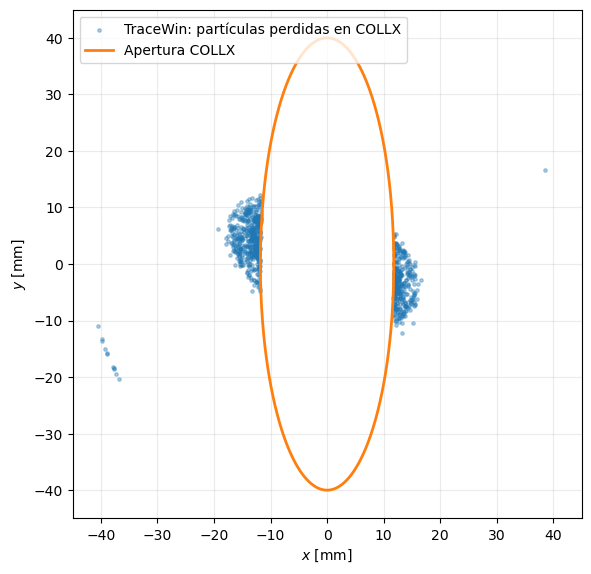

Guardado OPAL en: losses/losses_opal_COLLX.pdf
Guardado TraceWin en: losses/losses_tracewin_COLLX.pdf


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Lectura de pérdidas OPAL
# ============================================================

opal_cols = ["x", "y", "z", "px", "py", "pz", "id", "time"]

def read_opal_loss_file(file):
    file = Path(file)

    df = pd.read_csv(
        file,
        sep=r"\s+",
        comment="#",
        names=opal_cols
    )

    df["id"] = df["id"].astype(int)

    df["x_mm"] = df["x"] * 1e3
    df["y_mm"] = df["y"] * 1e3
    df["z_mm"] = df["z"] * 1e3

    df["xp_mrad"] = df["px"] / df["pz"] * 1e3
    df["yp_mrad"] = df["py"] / df["pz"] * 1e3

    return df


# ============================================================
# Lectura de pérdidas TraceWin
# ============================================================
#
# Formato:
# #ele Pos(m) X_aper(m) Y_aper(m) x(m) xp(rad) y(m) yp(rad) p(rad) W(MeV)
#
# x está en la columna x(m)
# y está en la columna y(m)
# ============================================================

tracewin_cols = [
    "ele",
    "s",
    "x_aper",
    "y_aper",
    "x",
    "xp",
    "y",
    "yp",
    "p",
    "W"
]

def read_tracewin_loss_file(file):
    file = Path(file)

    df = pd.read_csv(
        file,
        sep=r"\s+",
        comment="#",
        names=tracewin_cols
    )

    # Nos quedamos solo con las filas que tienen x e y
    df = df.dropna(subset=["x", "y"]).copy()

    df["x_mm"] = df["x"] * 1e3
    df["y_mm"] = df["y"] * 1e3

    df["xp_mrad"] = df["xp"] * 1e3
    df["yp_mrad"] = df["yp"] * 1e3

    return df


# ============================================================
# Cargar archivos
# ============================================================

loss_opal = read_opal_loss_file("COLLX.loss")
loss_tracewin = read_tracewin_loss_file("Losses_Tracewin.dat")


# ============================================================
# Apertura del colimador COLLX
# ============================================================

xsize_mm = 0.0118 * 1e3
ysize_mm = 0.0400 * 1e3

t = np.linspace(0, 2 * np.pi, 500)

x_ell = xsize_mm * np.cos(t)
y_ell = ysize_mm * np.sin(t)


# ============================================================
# Guardar plots en PDFs separados
# ============================================================

outdir = Path("losses")
outdir.mkdir(parents=True, exist_ok=True)


# ============================================================
# Plot OPAL
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    loss_opal["x_mm"],
    loss_opal["y_mm"],
    s=6,
    alpha=0.35,
    label="OPAL: partículas perdidas en COLLX"
)

ax.plot(
    x_ell,
    y_ell,
    color="tab:orange",
    lw=2,
    label="Apertura COLLX"
)

ax.set_xlabel(r"$x$ [mm]")
ax.set_ylabel(r"$y$ [mm]")

ax.set_xlim(-45, 45)
ax.set_ylim(-45, 45)

ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left")

plt.tight_layout()

fig.savefig(
    outdir / "losses_opal_COLLX.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Plot TraceWin
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    loss_tracewin["x_mm"],
    loss_tracewin["y_mm"],
    s=6,
    alpha=0.35,
    label="TraceWin: partículas perdidas en COLLX"
)

ax.plot(
    x_ell,
    y_ell,
    color="tab:orange",
    lw=2,
    label="Apertura COLLX"
)

ax.set_xlabel(r"$x$ [mm]")
ax.set_ylabel(r"$y$ [mm]")

ax.set_xlim(-45, 45)
ax.set_ylim(-45, 45)

ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left")

plt.tight_layout()

fig.savefig(
    outdir / "losses_tracewin_COLLX.pdf",
    bbox_inches="tight"
)

plt.show()

print(f"Guardado OPAL en: {outdir / 'losses_opal_COLLX.pdf'}")
print(f"Guardado TraceWin en: {outdir / 'losses_tracewin_COLLX.pdf'}")